In [1]:
# JMP 2024 data update on WASH in health care facilities
# https://washdata.org/how-we-work/country-and-regional-engagement/regional-analysis-2024-health-care-facilities

import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file and select the correct sheet
df = pd.read_excel("../data/JMP-2024-wash-hcf-World-snapshot.xlsx", sheet_name="T1_Data")

# View the top few rows
df.head(21)



,name,year,urb,wat_bas_t,wat_lim_t,wat_ns_t,wat_imp_t,wat_imop_t,wat_bas_u,wat_lim_u,...,clean_ns_g,clean_pro_g,clean_trn_g,clean_bas_ng,clean_lim_ng,clean_ns_ng,clean_pro_ng,clean_trn_ng,sl,iso3
0,Afghanistan,2023,26.932999,79.00000,16.500000,4.500000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,AFG
1,Albania,2023,64.603004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,ALB
2,American Samoa,2023,87.235001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,ASM
3,Andorra,2023,87.774002,100.00000,0.000000,0.000000,100.000000,100.00000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,AND
4,Angola,2023,68.687996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,AGO
5,Anguilla,2023,100.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,AIA
6,Antigua and Barbuda,2023,24.332001,NaN,NaN,0.000000,100.000000,100.00000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,ATG
7,Armenia,2023,63.739002,97.65000,2.350000,0.000000,100.000000,98.80000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,ARM
8,Austria,2023,59.530003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,AUT
9,Azerbaijan,2023,57.577003,100.00000,0.000000,0.000000,100.000000,100.00000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,AZE


In [2]:
import seaborn as sns

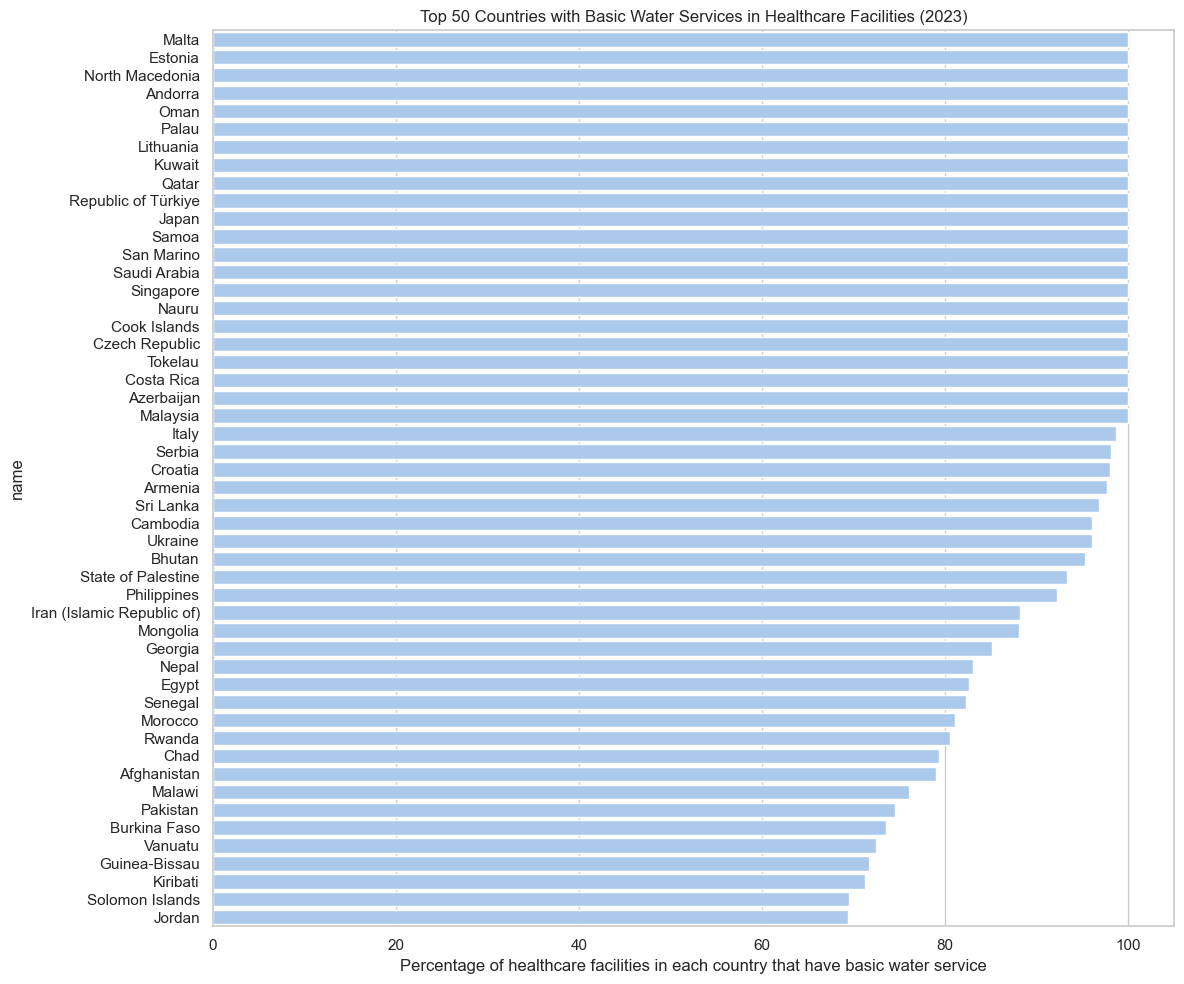

In [ ]:
# Load Excel sheet
df = pd.read_excel("../data/JMP-2024-wash-hcf-World-snapshot.xlsx", sheet_name="T1_Data")

# Drop rows that do not have data for 'wat_bas_t' (percentage with basic water service)
df_filtered = df.dropna(subset=['wat_bas_t'])

# Sort the data by highest percentage of basic water service and keep only the top 50 countries
top50 = df_filtered.sort_values(by='wat_bas_t', ascending=False).head(50)

# Set the visual style and color palette for the plot using Seaborn
sns.set(style="whitegrid")
sns.set_palette("pastel")  # or "muted", "deep", "colorblind" 

# Create the bar chart
plt.figure(figsize=(12, 10))
sns.barplot(x=top50['wat_bas_t'], y=top50['name'])  

# Label the axes and title the chart
plt.xlabel("Percentage of healthcare facilities in each country that have basic water service")
plt.title("Top 50 Countries with Basic Water Services in Healthcare Facilities (2023)")

# Optimize layout to prevent label cutoff
plt.tight_layout()

# Display 
plt.show()

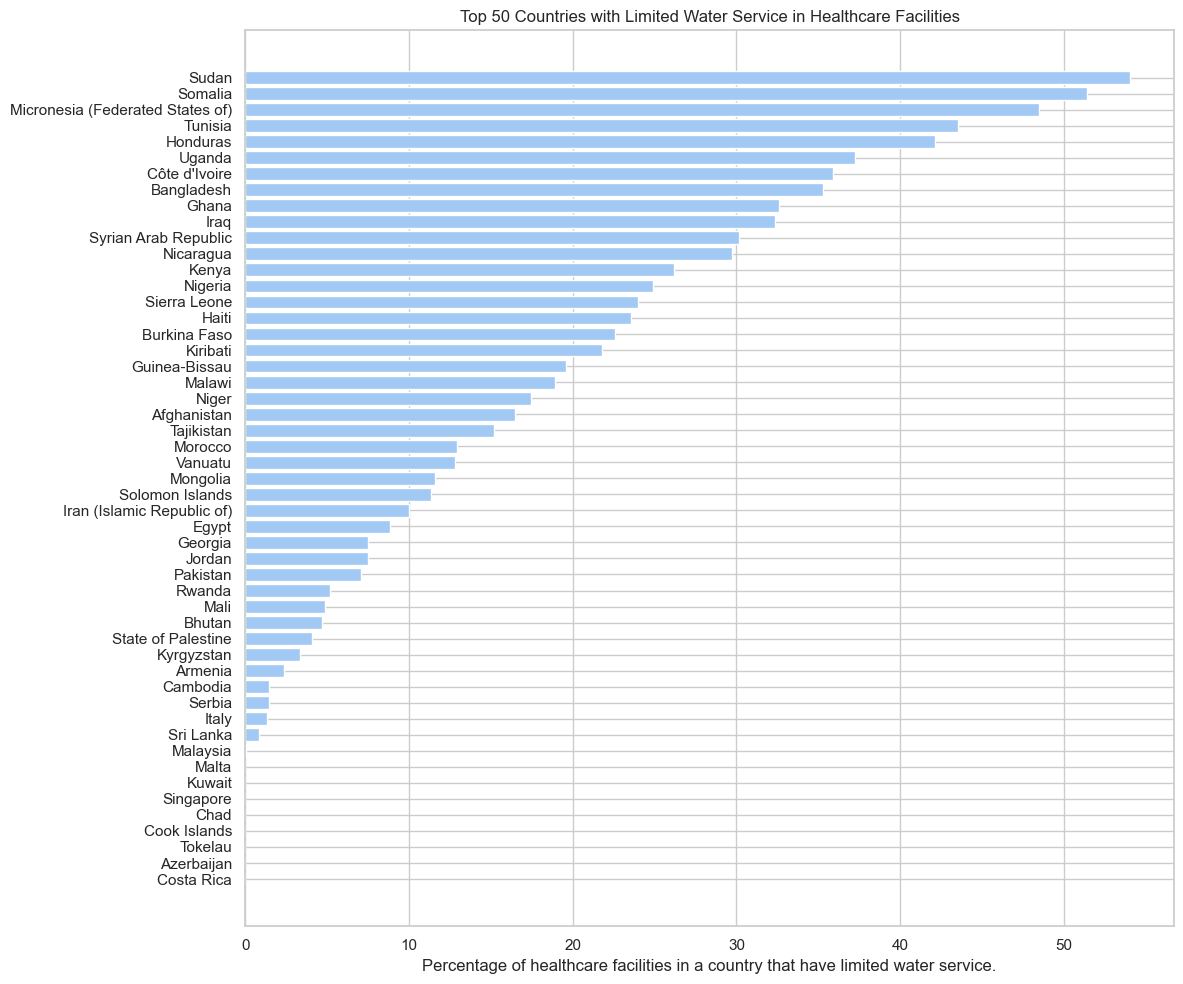

In [ ]:
#Select only the relevant columns and drop rows with missing values in 'wat_lim_t'
top_limited = df[['name', 'wat_lim_t']].dropna()

#Sort by 'wat_lim_t' in descending order and keep only the top 50
top_limited = top_limited.sort_values(by='wat_lim_t', ascending=False).head(51)

# create plot
plt.figure(figsize=(12, 10))
plt.barh(top_limited['name'], top_limited['wat_lim_t'])
#Add labels and title
plt.xlabel("Percentage of healthcare facilities in a country that have limited water service.")
plt.title("Top 50 Countries with Limited Water Service in Healthcare Facilities")

# Invert the y-axis so the country with the highest percentage will show at the top
plt.gca().invert_yaxis()
plt.tight_layout()

#display
plt.show()


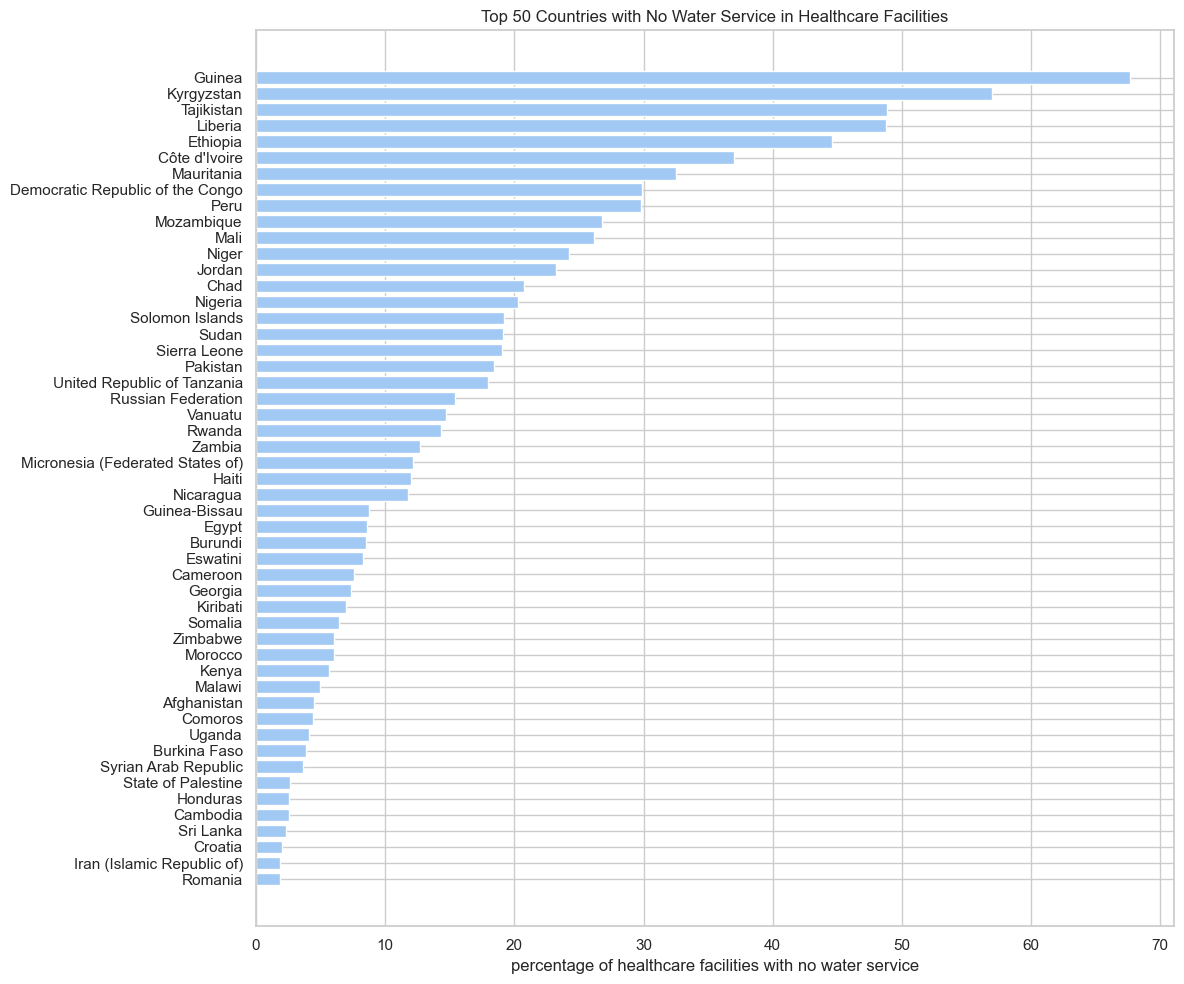

In [ ]:
#  Top 50 Countries with No Water Service

#Select relevant columns and remove rows where 'wat_ns_t' (no water service %) is missing
top_none = df[['name', 'wat_ns_t']].dropna()

# Sort countries by highest percentage of healthcare facilities with no water service
top_none = top_none.sort_values(by='wat_ns_t', ascending=False).head(51)

# Plot
plt.figure(figsize=(12, 10))
plt.barh(top_none['name'], top_none['wat_ns_t'])
plt.xlabel("percentage of healthcare facilities with no water service")
plt.title("Top 50 Countries with No Water Service in Healthcare Facilities")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


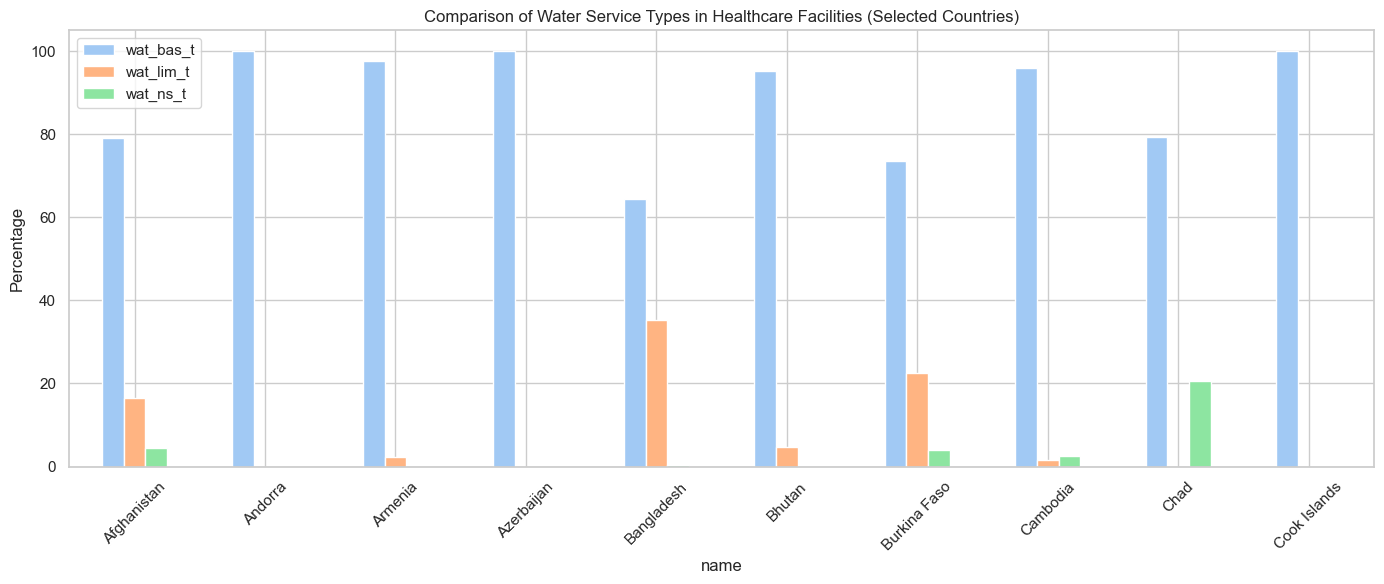

In [ ]:
# Can select later on which countries we want to display to be specific

# Filter the DataFrame to keep only countries that have non-null values 
# for all three water service indicators: basic, limited, and no service
grouped = df[['name', 'wat_bas_t', 'wat_lim_t', 'wat_ns_t']].dropna().head(10)

# Set country names as the index for easier plotting
grouped.set_index('name', inplace=True)

# Plot grouped bars
grouped.plot(kind='bar', figsize=(14, 6))
plt.title("Comparison of Water Service Types in Healthcare Facilities (Selected Countries)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Do countries with better access to basic water also tend to have better cleanliness (hygiene) infrastructure in healthcare?
More water service = more cleanliness

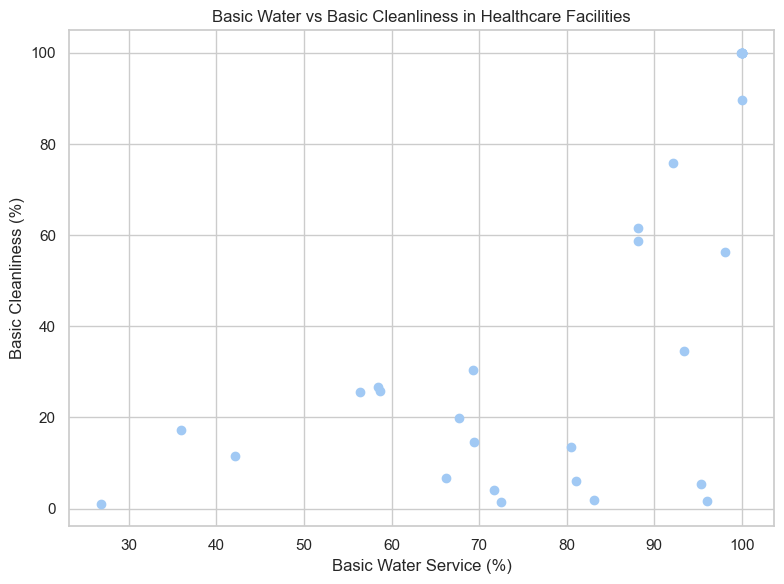

In [ ]:
# Select relevant columns for the scatter plot and drop rows with missing values
# 'wat_bas_t' = % of healthcare facilities with basic water service
# 'clean_bas_g' = % of healthcare facilities meeting basic cleanliness standards
scatter_data = df[['wat_bas_t', 'clean_bas_g']].dropna()

# Create a scatter plot to visualize the relationship between water and cleanliness
plt.figure(figsize=(8, 6))
plt.scatter(scatter_data['wat_bas_t'], scatter_data['clean_bas_g'])
plt.xlabel("Basic Water Service (%)")
plt.ylabel("Basic Cleanliness (%)")
plt.title("Basic Water vs Basic Cleanliness in Healthcare Facilities")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Select only necessary columns + remove any rows with missing values
# 'wat_bas_t' = % of healthcare facilities with basic water service
# 'clean_bas_g' = % with basic cleanliness services
scatter_data = df[['wat_bas_t', 'clean_bas_g']].dropna()

# Create Plotly scatter plot
fig = px.scatter(
    scatter_data,
    x='wat_bas_t', # X-axis: % with basic water service
    y='clean_bas_g', # Y-axis: % with basic cleanliness
    labels={
        'wat_bas_t': 'Basic Water Service (%)',
        'clean_bas_g': 'Basic Cleanliness (%)'
    },
    title='Basic Water vs Basic Cleanliness in Healthcare Facilities',
    template='plotly_white'
)

# Customize layout for size and spacing
fig.update_layout(
    height=500,
    width=800,
    margin=dict(l=40, r=40, t=60, b=40)
)

# Export to HTML
fig.write_html("../visualizations/scatter_water_cleanliness.html")


In [ ]:
import pandas as pd
import os

#  Load the Excel file
df = pd.read_excel("../data/JMP-2024-wash-hcf-World-snapshot.xlsx", sheet_name="T1_Data")

# Select key indicators and remove rows with missing values
# Columns:
# - 'wat_lim_t': % of facilities with limited water service
# - 'wat_ns_t': % with no water service
# - 'wat_bas_t': % with basic water service
# - 'clean_bas_g': % with basic cleanliness
summary_df = df[['name', 'wat_lim_t', 'wat_ns_t', 'wat_bas_t', 'clean_bas_g']].dropna()

# Rename the columns for clarity and consistency
summary_df.columns = [
    'Country',
    'Limited Water Service (%)',
    'No Water Service (%)',
    'Basic Water Service (%)',
    'Basic Cleanliness (%)'
]

# Just to make sure that the target directory exists
os.makedirs("data", exist_ok=True)

#  Save to CSV for Froggy 
summary_df.to_csv("../data/data_froggy/jmp_healthcare_water_cleanliness_summary.csv", index=False)
